# **Outlier Handling**
### **Outliers:**
 - Data points that significantly deviate from the normal data.
 ### **Methods:**
 - 1. Clipping
 - 2. Winsorization
 - 3. Removal
 ------------------


# 1. Import Libraries

In [20]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize

# 2. Create Series

In [21]:
# create dataframe of sales data
df = pd.DataFrame({
    "Sales": [100, 200, 150, 300, 5000, 7000, 3000, 1500, 600, 400]
        })
df.describe()

,Sales
count,10.00000
mean,1825.00000
std,2418.13174
min,100.00000
25%,225.00000
50%,500.00000
75%,2625.00000
max,7000.00000


# 3. Boxplot for Outlier Detection

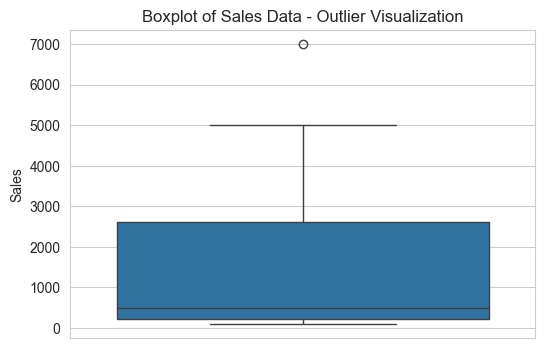

In [22]:
# boxplot to visualize outliers
plt.figure(figsize = (6, 4))
sns.boxplot(data = df, y = "Sales")
plt.title("Boxplot of Sales Data - Outlier Visualization")
plt.show()

# 4. Remove Outliers 
## 4.1 Clipping Method

In [23]:
# clipping method
df["sales_clipped"] = df["Sales"].clip(lower = 150, upper = 3000)
print(df)

   Sales  sales_clipped
0    100            150
1    200            200
2    150            150
3    300            300
4   5000           3000
5   7000           3000
6   3000           3000
7   1500           1500
8    600            600
9    400            400


# 4.2 Boxplot for Clipped Data

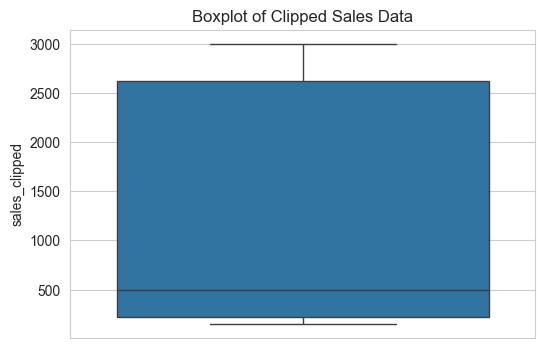

In [24]:
# box plot
sns.set_style("whitegrid")
plt.figure(figsize = (6, 4))
sns.boxplot(data = df, y = "sales_clipped")
plt.title("Boxplot of Clipped Sales Data")
plt.show()

# 4.3 Winsorization Method

In [25]:
# winsorization (top 20% capped)
df["sales_winsorized"] = winsorize(df["Sales"], limits  = [0, 0.2])
print(df)

   Sales  sales_clipped  sales_winsorized
0    100            150               100
1    200            200               200
2    150            150               150
3    300            300               300
4   5000           3000              3000
5   7000           3000              3000
6   3000           3000              3000
7   1500           1500              1500
8    600            600               600
9    400            400               400


# 4.4 Removal

In [27]:
# drop outliers > 1000
df["sales_dropped"] = df["Sales"].where(df["Sales"] <= 1000, np.nan)
print(df)

   Sales  sales_clipped  sales_winsorized  sales_dropped
0    100            150               100          100.0
1    200            200               200          200.0
2    150            150               150          150.0
3    300            300               300          300.0
4   5000           3000              3000            NaN
5   7000           3000              3000            NaN
6   3000           3000              3000            NaN
7   1500           1500              1500            NaN
8    600            600               600          600.0
9    400            400               400          400.0


# 5. Boxplot for All

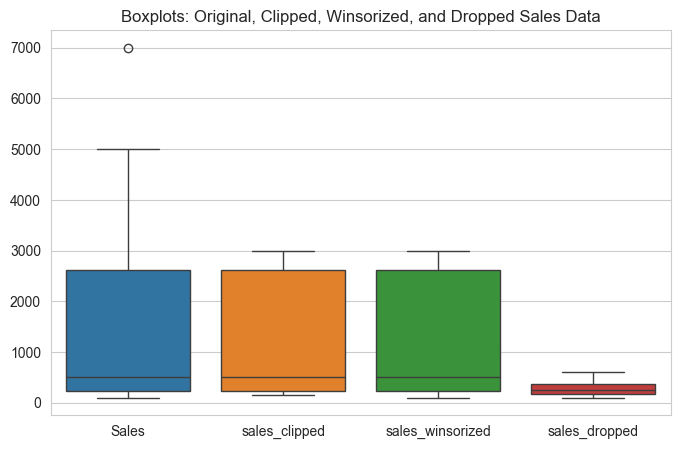

In [28]:
plt.figure(figsize = (8, 5))
sns.boxplot(data = df[["Sales", "sales_clipped", "sales_winsorized", "sales_dropped"]])
plt.title("Boxplots: Original, Clipped, Winsorized, and Dropped Sales Data")
plt.show()
